## Inteligență Artificială  Tema 1 - 2025: Sokoban

Responsabili:
- Andrei Olaru
- Cătălin Chiru
- Andrei Dugăeșescu
- Mihai Nan
- Vlad Matei Drăghici
- Alexandru Baciu
- Bogdan-Andrei Sprîncenatu

# Imports

In [1]:
from sokoban import Map, save_images, create_gif
import time
from search_methods.lrta_star import LRTAStar
from search_methods.simmulated_annealing import SimulatedAnnealing

# Test Map

In [2]:
test_maps = [
    'tests/easy_map1.yaml',
    'tests/easy_map2.yaml',
    'tests/medium_map1.yaml',
    'tests/medium_map2.yaml',
    'tests/hard_map1.yaml',
    'tests/hard_map2.yaml',
    'tests/large_map1.yaml',
    'tests/large_map2.yaml',
    'tests/super_hard_map1.yaml'
]

# Test LRTA* solver

In [9]:
sokoban_map = Map.from_yaml(test_maps[3])
print("Testing LRTA* solver:")
lrta_solver = LRTAStar(max_iterations=50000)
start_time = time.time()
solution = lrta_solver.solve(sokoban_map)
solve_time = time.time() - start_time
if solution:
    print(f"Solution found with {len(solution)} moves")
    print(f"Pull moves used: {sum(1 for move in solution if move >= 4)}")
    print(f"Time taken: {solve_time:.2f} seconds")

    # Show final state after LRTA*
    final_state = Map.from_yaml('tests/easy_map1.yaml')
    for move in solution:
        final_state.apply_move(move)
    print("\nInitial state:")
    sokoban_map.plot_map()
    print("\nFinal state:")
    final_state.plot_map()
    final_state.save_map('images', 'lrta_solution.png')

Testing LRTA* solver:


# Test Simulated easy

Solution found with 1155 moves
Pull moves used: 289
Time taken: 0.30 seconds

Initial state:


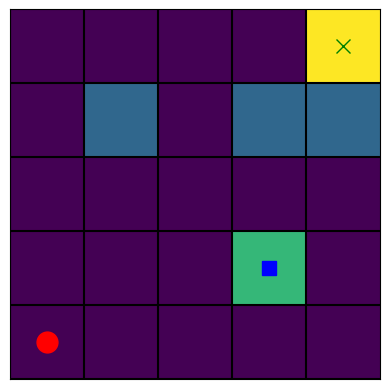


Final state:


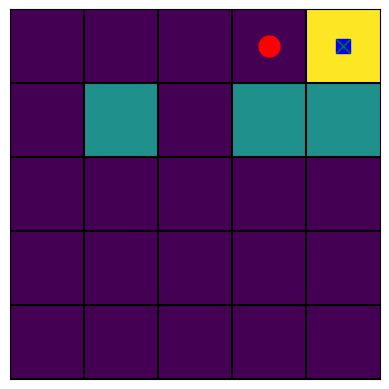

In [4]:
sa_solver = SimulatedAnnealing(initial_temp=100, cooling_rate=0.99)
start_time = time.time()
sokoban_map = Map.from_yaml('tests/easy_map1.yaml')
solution = sa_solver.solve(sokoban_map)
solve_time = time.time() - start_time

if solution:
    print(f"Solution found with {len(solution)} moves")
    print(f"Pull moves used: {sum(1 for move in solution if move >= 4)}")
    print(f"Time taken: {solve_time:.2f} seconds")

    # Show final state after Simulated Annealing
    final_state = Map.from_yaml('tests/easy_map1.yaml')
    for move in solution:
        final_state.apply_move(move)
    print("\nInitial state:")
    sokoban_map.plot_map()
    print("\nFinal state:")
    final_state.plot_map()
    final_state.save_map('images', 'sa_solution.png')

# Test Both  LRTA* and Simulated Annealing with all maps


Testing map: tests/easy_map1.yaml

Testing LRTAStar on tests/easy_map1.yaml

Initial state:


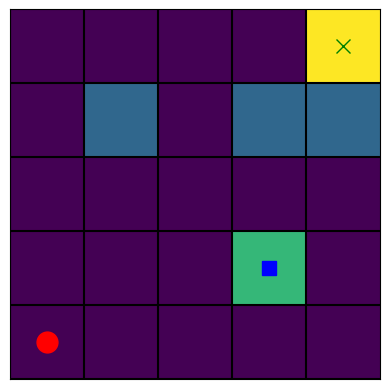

✓ Solution found with 4319 moves
✓ Pull moves used: 892
✓ Time taken: 0.33 seconds

Final state:


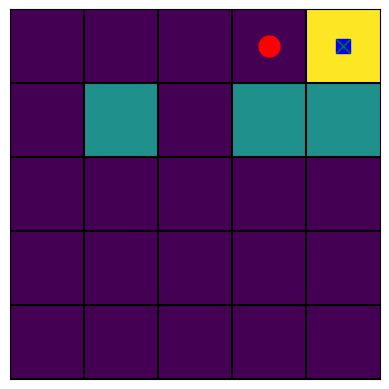


Testing SimulatedAnnealing on tests/easy_map1.yaml

Initial state:


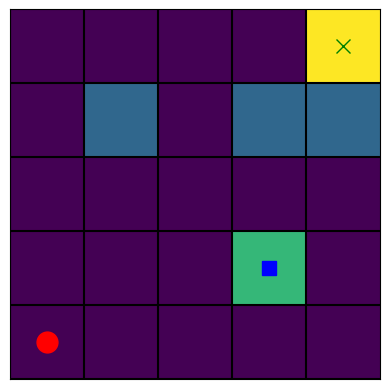

✓ Solution found with 475 moves
✓ Pull moves used: 131
✓ Time taken: 0.03 seconds

Final state:


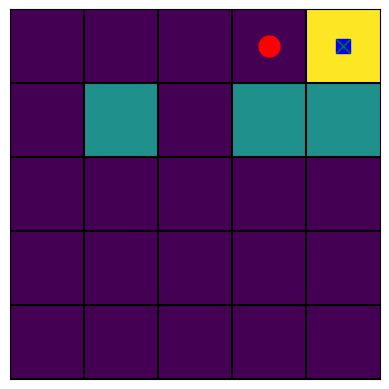


Comparison:
LRTA*: Solved ✓
SimulatedAnnealing: Solved ✓

Testing map: tests/easy_map2.yaml

Testing LRTAStar on tests/easy_map2.yaml

Initial state:


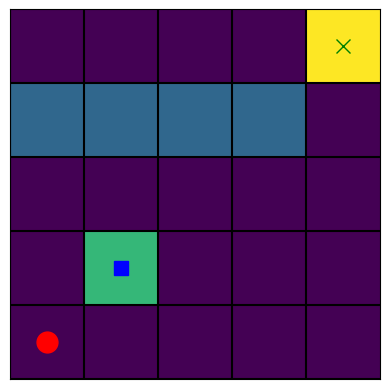

✓ Solution found with 95 moves
✓ Pull moves used: 12
✓ Time taken: 0.02 seconds

Final state:


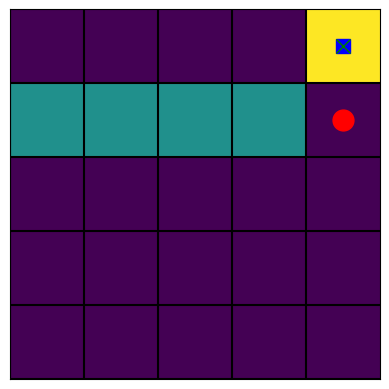


Testing SimulatedAnnealing on tests/easy_map2.yaml

Initial state:


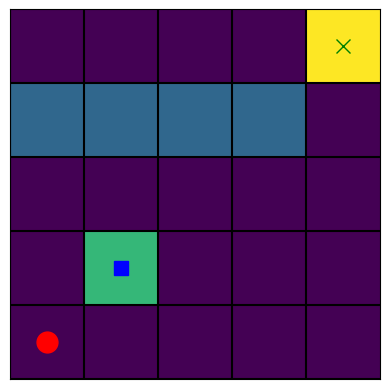

✓ Solution found with 169 moves
✓ Pull moves used: 37
✓ Time taken: 0.03 seconds

Final state:


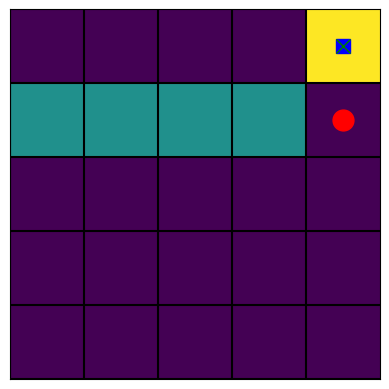


Comparison:
LRTA*: Solved ✓
SimulatedAnnealing: Solved ✓

Testing map: tests/medium_map1.yaml

Testing LRTAStar on tests/medium_map1.yaml

Initial state:


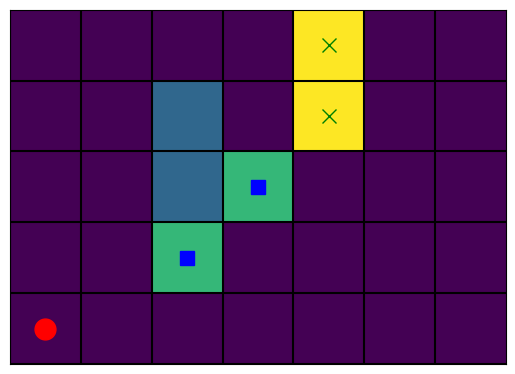

✗ No solution found

Testing SimulatedAnnealing on tests/medium_map1.yaml

Initial state:


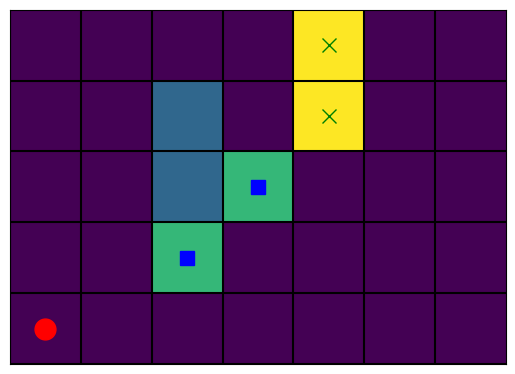

✓ Solution found with 4362 moves
✓ Pull moves used: 1243
✓ Time taken: 0.77 seconds

Final state:


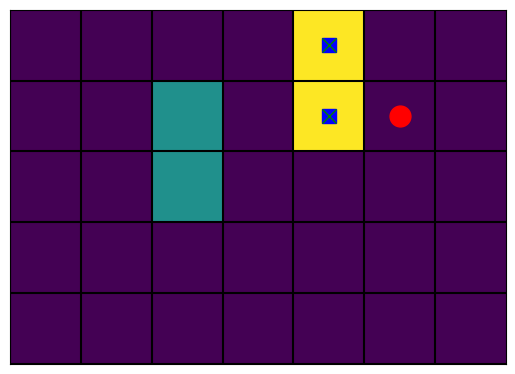


Comparison:
LRTA*: Failed ✗
SimulatedAnnealing: Solved ✓

Testing map: tests/medium_map2.yaml

Testing LRTAStar on tests/medium_map2.yaml

Initial state:


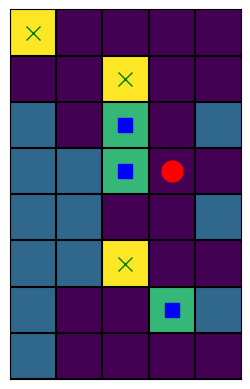

✗ No solution found

Testing SimulatedAnnealing on tests/medium_map2.yaml

Initial state:


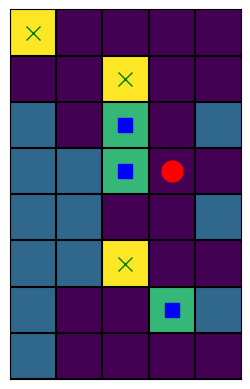

✗ No solution found

Comparison:
LRTA*: Failed ✗
SimulatedAnnealing: Failed ✗


In [5]:
from sokoban.map import Map
from search_methods.lrta_star import LRTAStar
from search_methods.simmulated_annealing import SimulatedAnnealing

def test_solver(solver, map_path, show_plots=True):
    print(f"\nTesting {solver.__class__.__name__} on {map_path}")
    sokoban_map = Map.from_yaml(map_path)

    if show_plots:
        print("\nInitial state:")
        sokoban_map.plot_map()

    start_time = time.time()
    solution = solver.solve(sokoban_map)
    solve_time = time.time() - start_time

    if solution:
        print(f"✓ Solution found with {len(solution)} moves")
        print(f"✓ Pull moves used: {sum(1 for move in solution if move >= 4)}")
        print(f"✓ Time taken: {solve_time:.2f} seconds")

        # Show final state
        final_state = Map.from_yaml(map_path)
        for move in solution:
            final_state.apply_move(move)

        if show_plots:
            print("\nFinal state:")
            final_state.plot_map()

        # Save visualization
        output_name = f"{solver.__class__.__name__.lower()}_{map_path.split('/')[-1].replace('.yaml', '')}"
        final_state.save_map('images', f'{output_name}_solution.png')
        return True
    else:
        print("✗ No solution found")
        return False

# Test maps with both solvers
for map_path in test_maps[:4]:  # Start with first 4 maps (easy and medium)
    print("\n" + "="*50)
    print(f"Testing map: {map_path}")
    print("="*50)

    # Test LRTA*
    lrta_solver = LRTAStar(max_iterations=50000)
    lrta_success = test_solver(lrta_solver, map_path)

    # Test Simulated Annealing
    sa_solver = SimulatedAnnealing(
        initial_temp=100.0,
        cooling_rate=0.995,
        min_temp=0.01,
        max_iterations=10000
    )
    sa_success = test_solver(sa_solver, map_path)

    # Print comparison
    print("\nComparison:")
    print(f"LRTA*: {'Solved ✓' if lrta_success else 'Failed ✗'}")
    print(f"SimulatedAnnealing: {'Solved ✓' if sa_success else 'Failed ✗'}")

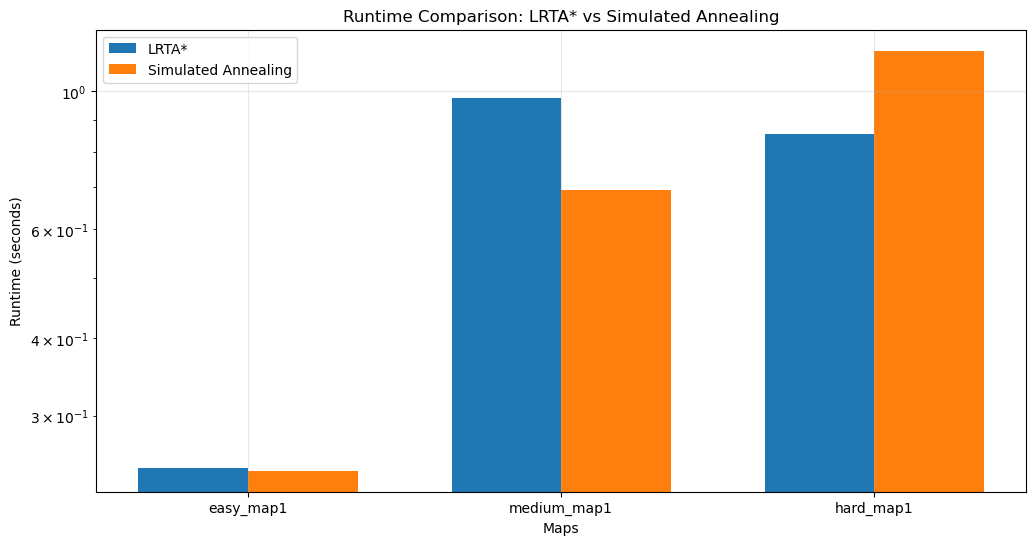

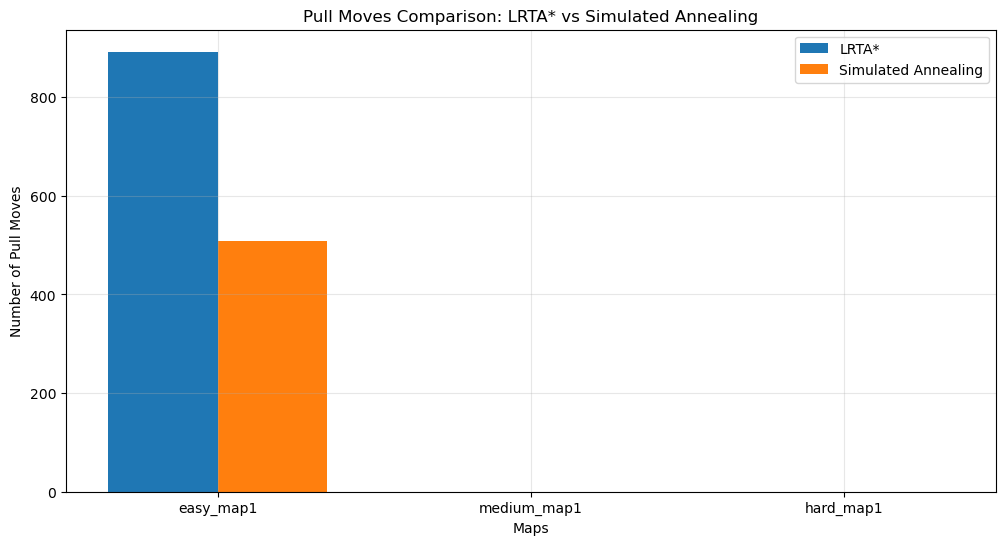


Detailed Statistics:
--------------------------------------------------

Map: easy_map1
LRTA*:
  Time: 0.25 seconds
  Total moves: 4319
  Pull moves: 892
  Solved: True

Simulated Annealing:
  Time: 0.24 seconds
  Total moves: 1967
  Pull moves: 507
  Solved: True

Map: medium_map1
LRTA*:
  Time: 0.98 seconds
  Total moves: 0
  Pull moves: 0
  Solved: False

Simulated Annealing:
  Time: 0.69 seconds
  Total moves: 0
  Pull moves: 0
  Solved: False

Map: hard_map1
LRTA*:
  Time: 0.85 seconds
  Total moves: 0
  Pull moves: 0
  Solved: False

Simulated Annealing:
  Time: 1.16 seconds
  Total moves: 0
  Pull moves: 0
  Solved: False


In [12]:
# Import required libraries for analysis
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import os

# Create a function to run tests and collect metrics
def run_analysis(solver, map_files, heuristics=None):
    results = defaultdict(dict)

    for map_file in map_files:
        map_name = os.path.basename(map_file).replace('.yaml', '')
        sokoban_map = Map.from_yaml(map_file)

        # Run solver
        start_time = time.time()
        solution = solver.solve(sokoban_map)
        solve_time = time.time() - start_time

        # Collect metrics
        results[map_name] = {
            'time': solve_time,
            'moves': len(solution) if solution else 0,
            'pull_moves': sum(1 for move in solution if move >= 4) if solution else 0,
            'solved': solution is not None
        }

    return results

# List of test maps
test_maps = [
    'tests/easy_map1.yaml',
    'tests/medium_map1.yaml',
    'tests/hard_map1.yaml'
]

# Run analysis for both solvers
lrta_solver = LRTAStar(max_iterations=10000)
sa_solver = SimulatedAnnealing(initial_temp=100, cooling_rate=0.99)

lrta_results = run_analysis(lrta_solver, test_maps)
sa_results = run_analysis(sa_solver, test_maps)

# Create bar plot for solution times
plt.figure(figsize=(12, 6))
maps = list(lrta_results.keys())
lrta_times = [lrta_results[m]['time'] for m in maps]
sa_times = [sa_results[m]['time'] for m in maps]

x = np.arange(len(maps))
width = 0.35

plt.bar(x - width/2, lrta_times, width, label='LRTA*')
plt.bar(x + width/2, sa_times, width, label='Simulated Annealing')

plt.xlabel('Maps')
plt.ylabel('Runtime (seconds)')
plt.title('Runtime Comparison: LRTA* vs Simulated Annealing')
plt.xticks(x, maps)
plt.legend()
plt.yscale('log')  # Use log scale for better visualization
plt.grid(True, alpha=0.3)
plt.show()

# Create bar plot for pull moves
plt.figure(figsize=(12, 6))
lrta_pulls = [lrta_results[m]['pull_moves'] for m in maps]
sa_pulls = [sa_results[m]['pull_moves'] for m in maps]

plt.bar(x - width/2, lrta_pulls, width, label='LRTA*')
plt.bar(x + width/2, sa_pulls, width, label='Simulated Annealing')

plt.xlabel('Maps')
plt.ylabel('Number of Pull Moves')
plt.title('Pull Moves Comparison: LRTA* vs Simulated Annealing')
plt.xticks(x, maps)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print detailed statistics
print("\nDetailed Statistics:")
print("-" * 50)
for map_name in maps:
    print(f"\nMap: {map_name}")
    print("LRTA*:")
    print(f"  Time: {lrta_results[map_name]['time']:.2f} seconds")
    print(f"  Total moves: {lrta_results[map_name]['moves']}")
    print(f"  Pull moves: {lrta_results[map_name]['pull_moves']}")
    print(f"  Solved: {lrta_results[map_name]['solved']}")

    print("\nSimulated Annealing:")
    print(f"  Time: {sa_results[map_name]['time']:.2f} seconds")
    print(f"  Total moves: {sa_results[map_name]['moves']}")
    print(f"  Pull moves: {sa_results[map_name]['pull_moves']}")
    print(f"  Solved: {sa_results[map_name]['solved']}")


Running LRTA* tests...

Testing easy_map1 with LRTAStar
✓ Solved in 0.62s with 4319 moves (892 pulls)

Testing easy_map2 with LRTAStar
✓ Solved in 0.01s with 95 moves (12 pulls)

Testing medium_map1 with LRTAStar
✗ No solution found

Testing medium_map2 with LRTAStar
✗ No solution found

Testing hard_map1 with LRTAStar
✗ No solution found

Testing hard_map2 with LRTAStar
✗ No solution found

Testing large_map1 with LRTAStar
✗ No solution found

Testing large_map2 with LRTAStar
✗ No solution found

Testing super_hard_map1 with LRTAStar
✗ No solution found

Running Simulated Annealing tests...

Testing easy_map1 with SimulatedAnnealing
✓ Solved in 0.10s with 865 moves (211 pulls)

Testing easy_map2 with SimulatedAnnealing
✓ Solved in 0.17s with 1359 moves (329 pulls)

Testing medium_map1 with SimulatedAnnealing
✗ No solution found

Testing medium_map2 with SimulatedAnnealing
✗ No solution found

Testing hard_map1 with SimulatedAnnealing
✓ Solved in 0.70s with 1551 moves (552 pulls)

Tes

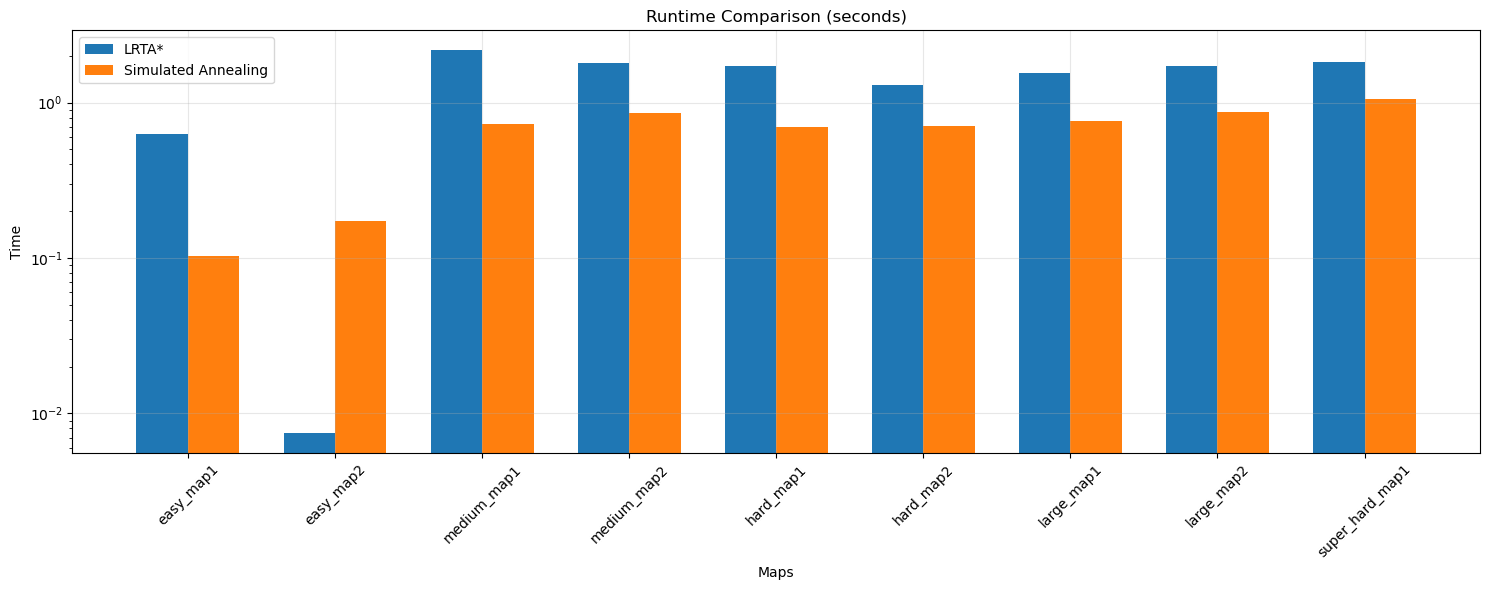

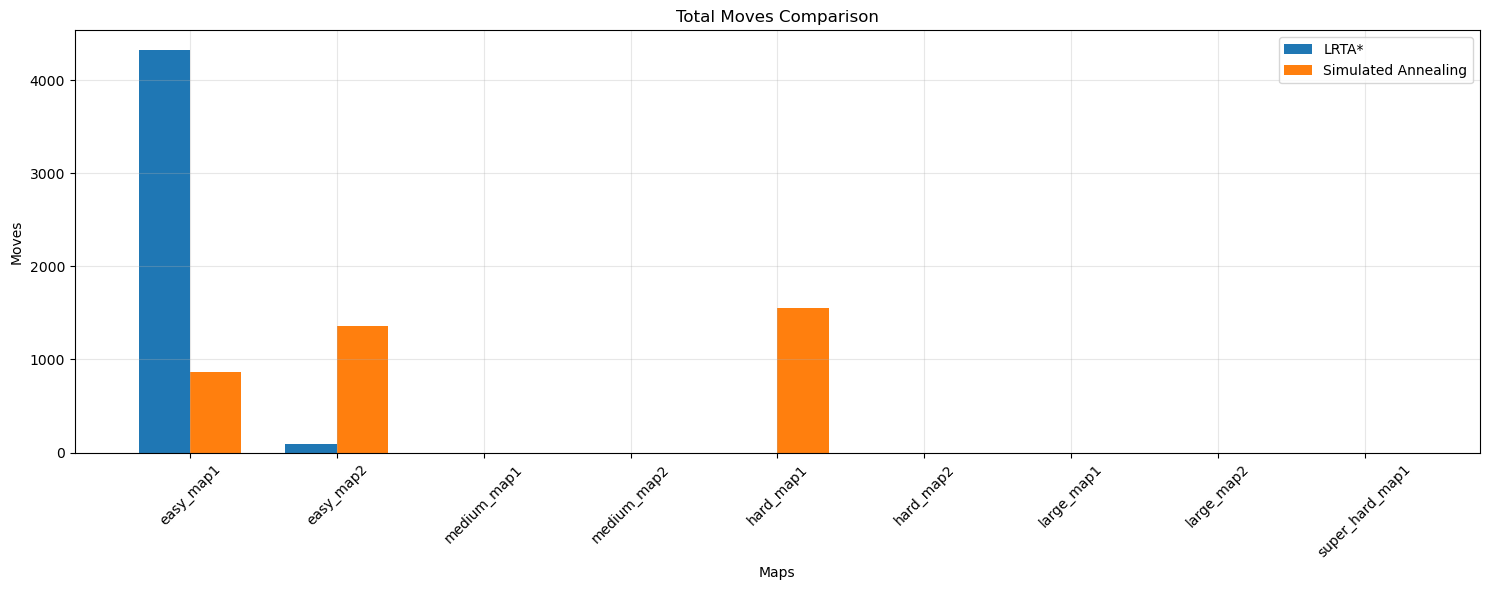

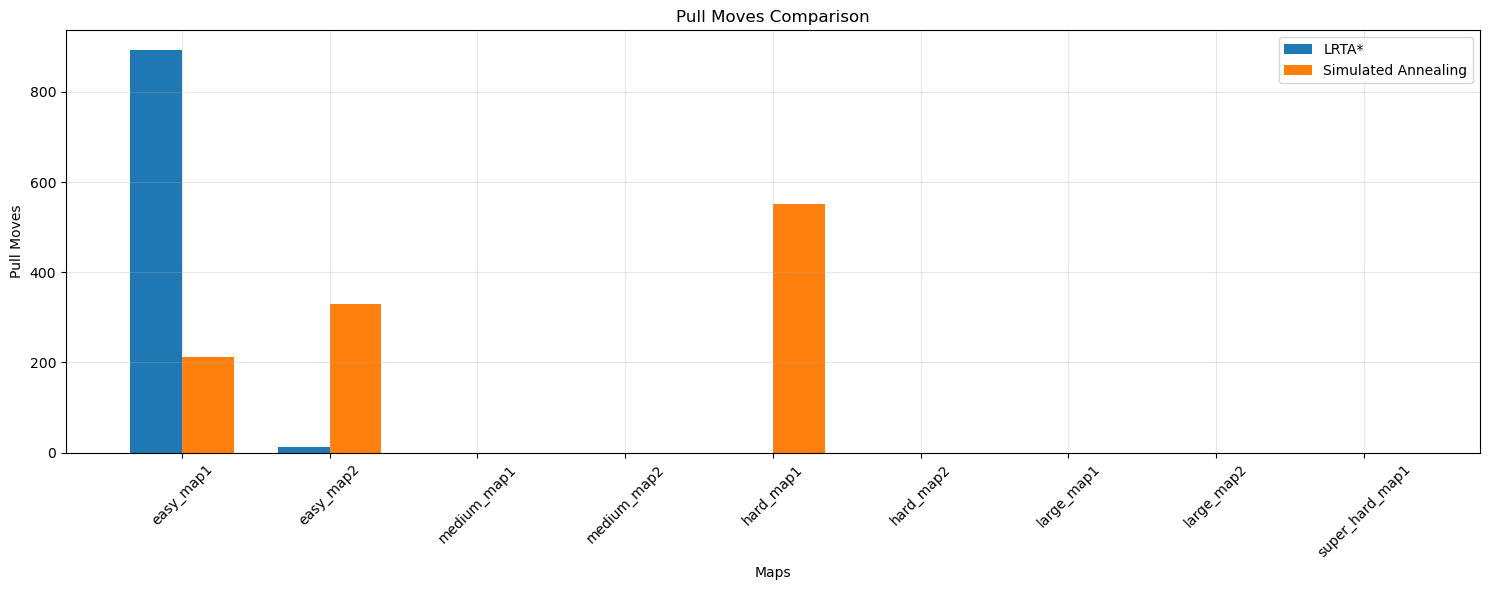


Summary Statistics:
--------------------------------------------------

LRTA*:
Solved 2/9 maps
Average time: 0.32s
Average moves: 2207.0
Average pull moves: 452.0

SimulatedAnnealing:
Solved 3/9 maps
Average time: 0.33s
Average moves: 1258.3
Average pull moves: 364.0


In [20]:
# Import required libraries
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import os
import time

# List all test maps
test_maps = [
    'tests/easy_map1.yaml',
    'tests/easy_map2.yaml',
    'tests/medium_map1.yaml',
    'tests/medium_map2.yaml',
    'tests/hard_map1.yaml',
    'tests/hard_map2.yaml',
    'tests/large_map1.yaml',
    'tests/large_map2.yaml',
    'tests/super_hard_map1.yaml'
]

# Function to run solver and collect metrics
def run_solver_test(solver, map_file, timeout=300):  # 5 minute timeout
    results = {}
    map_name = os.path.basename(map_file).replace('.yaml', '')
    print(f"\nTesting {map_name} with {solver.__class__.__name__}")

    try:
        # Load map
        sokoban_map = Map.from_yaml(map_file)

        # Run solver with timeout
        start_time = time.time()
        solution = solver.solve(sokoban_map)
        solve_time = time.time() - start_time

        if solution:
            results = {
                'status': 'solved',
                'time': solve_time,
                'moves': len(solution),
                'pull_moves': sum(1 for move in solution if move >= 4)
            }
            print(f"✓ Solved in {solve_time:.2f}s with {len(solution)} moves ({results['pull_moves']} pulls)")
        else:
            results = {
                'status': 'failed',
                'time': solve_time,
                'moves': 0,
                'pull_moves': 0
            }
            print("✗ No solution found")

    except Exception as e:
        results = {
            'status': 'error',
            'time': 0,
            'moves': 0,
            'pull_moves': 0,
            'error': str(e)
        }
        print(f"✗ Error: {str(e)}")

    return results

# Test both solvers
results = {
    'LRTA*': {},
    'SimulatedAnnealing': {}
}

# Run LRTA* tests
print("\nRunning LRTA* tests...")
for map_file in test_maps:
    solver = LRTAStar(max_iterations=20000)
    results['LRTA*'][map_file] = run_solver_test(solver, map_file)

# Run Simulated Annealing tests
print("\nRunning Simulated Annealing tests...")
for map_file in test_maps:
    solver = SimulatedAnnealing(initial_temp=100, cooling_rate=0.99)
    results['SimulatedAnnealing'][map_file] = run_solver_test(solver, map_file)

# Create comparison plots
def plot_comparison(metric='time', title=None):
    plt.figure(figsize=(15, 6))

    map_names = [os.path.basename(m).replace('.yaml', '') for m in test_maps]
    x = np.arange(len(map_names))
    width = 0.35

    lrta_values = [results['LRTA*'][m][metric] for m in test_maps]
    sa_values = [results['SimulatedAnnealing'][m][metric] for m in test_maps]

    plt.bar(x - width/2, lrta_values, width, label='LRTA*')
    plt.bar(x + width/2, sa_values, width, label='Simulated Annealing')

    plt.xlabel('Maps')
    plt.ylabel(metric.replace('_', ' ').title())
    plt.title(title or f'{metric.replace("_", " ").title()} Comparison')
    plt.xticks(x, map_names, rotation=45)
    plt.legend()

    if metric == 'time':
        plt.yscale('log')

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Generate comparison plots
plot_comparison('time', 'Runtime Comparison (seconds)')
plot_comparison('moves', 'Total Moves Comparison')
plot_comparison('pull_moves', 'Pull Moves Comparison')

# Print summary statistics
print("\nSummary Statistics:")
print("-" * 50)
for solver_name in results:
    print(f"\n{solver_name}:")
    solved = sum(1 for m in test_maps if results[solver_name][m]['status'] == 'solved')
    avg_time = np.mean([results[solver_name][m]['time'] for m in test_maps
                       if results[solver_name][m]['status'] == 'solved'])
    avg_moves = np.mean([results[solver_name][m]['moves'] for m in test_maps
                        if results[solver_name][m]['status'] == 'solved'])
    avg_pulls = np.mean([results[solver_name][m]['pull_moves'] for m in test_maps
                        if results[solver_name][m]['status'] == 'solved'])

    print(f"Solved {solved}/{len(test_maps)} maps")
    print(f"Average time: {avg_time:.2f}s")
    print(f"Average moves: {avg_moves:.1f}")
    print(f"Average pull moves: {avg_pulls:.1f}")